# Anomaly Exploration

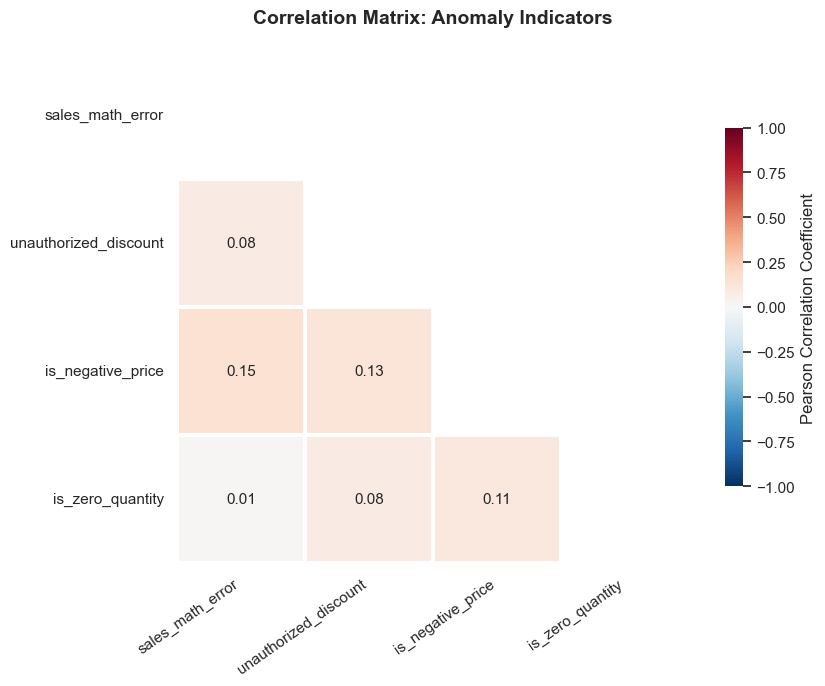

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your flagged transactions data
df = pd.read_csv("output/engineered_dataset2.csv")

# 1. Define only the specific anomaly columns from the dataset (Removed qty_zscore)
anomaly_cols = [
    "sales_math_error",
    "unauthorized_discount",
    "is_negative_price",
    "is_zero_quantity"
]

# Ensure we only try to plot columns that actually exist in the dataframe
valid_anomaly_cols = [col for col in anomaly_cols if col in df.columns]

# Set a professional, crisp plotting style
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16
})

plt.figure(figsize=(9, 7))

# Calculate correlation matrix
corr_matrix = df[valid_anomaly_cols].corr()

# Create a clean diagonal mask to hide redundant upper-triangle data
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the beautifully styled heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",          # Professional diverging palette
    vmin=-1.0, vmax=1.0,
    annot=True,
    fmt=".2f",
    square=True,            # Force cells to be perfectly square
    linewidths=1.5,         # Clean white grid lines separating cells
    cbar_kws={"shrink": 0.7, "label": "Pearson Correlation Coefficient"}
)

plt.title("Correlation Matrix: Anomaly Indicators", pad=20, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


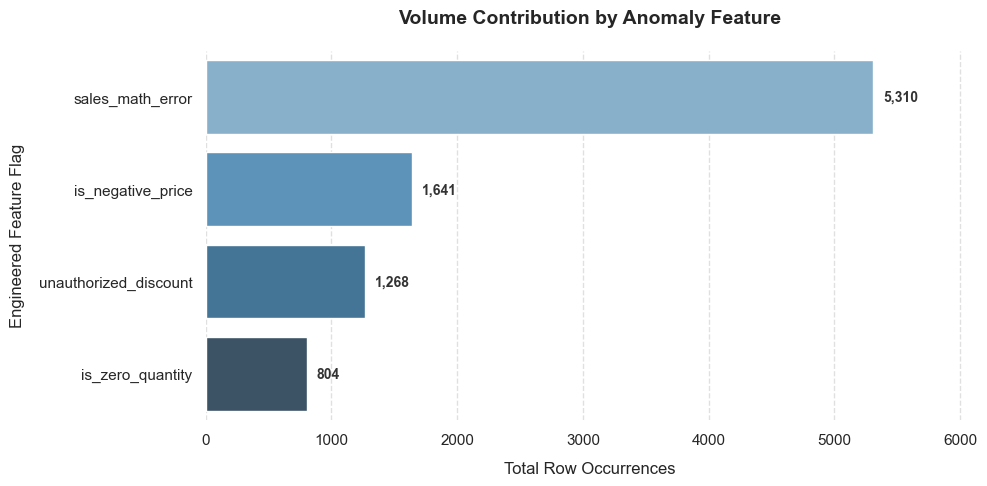

In [ ]:
anomaly_counts = {}

for col in valid_anomaly_cols:
    # Continuous features: Count rows where the error/deviation is mathematically significant
    if col in ["sales_math_error", "price_deviation"]:
        count = (df[col].abs() > 0.001).sum()
    # Binary features: Count rows where the flag was explicitly triggered (== 1)
    else:
        count = (df[col] > 0).sum()
        
    anomaly_counts[col] = count

# Convert to a Series and sort from highest to lowest frequency
counts_series = pd.Series(anomaly_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 5))

# Use a sophisticated, modern sequential palette
ax = sns.barplot(
    x=counts_series.values, 
    y=counts_series.index, 
    palette="Blues_d", 
    hue=counts_series.index, 
    legend=False
)

# Add an elegant, subtle vertical background grid
ax.xaxis.grid(True, linestyle="--", alpha=0.6, color="#CCCCCC")
ax.set_axisbelow(True)  # Keep grid lines safely behind the bars

# Direct labeling: Add neat, bold counts to the end of each bar
for i, count in enumerate(counts_series.values):
    ax.text(
        count + (counts_series.max() * 0.015), 
        i, 
        f"{int(count):,}", 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

# Clear up unnecessary chart ink (spines) for a minimalist look
sns.despine(left=True, bottom=True)

plt.title("Volume Contribution by Anomaly Feature", pad=20, fontweight="bold")
plt.xlabel("Total Row Occurrences", labelpad=10)
plt.ylabel("Engineered Feature Flag", labelpad=10)

# Provide horizontal buffer padding so labels never clipping-bleed off-screen
plt.xlim(0, counts_series.max() * 1.15 if counts_series.max() > 0 else 1)
plt.tight_layout()
plt.show()